# NB2 — Baseline walkthrough: the naive delayed-label pipeline that looks fine and is not

**Scope note.** This notebook is a **synthetic**, seeded walkthrough of the *naive* delayed/selected-label
pipeline — the one that treats unresolved outcomes as negatives and evaluates itself on the labels it
happened to receive. It is not production experience. The
sizes are reduced ("notebook demo sizes") so it executes in minutes; NB3 then reruns its corrected
counterpart from the same cache.

The point of the notebook is not that the baseline is badly written. It is that the baseline's own numbers
cannot show what is wrong with it: the labels it is scored on are the ones its own decision rule allowed
into the sample.

In [1]:
%matplotlib inline
import copy
import json
import pathlib
import sys

ROOT = pathlib.Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "label_delay" / "__init__.py").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from IPython.display import Image, display

import label_delay.notebook_support as exp
import label_delay.data as data_mod
import label_delay.evaluation as evaluation
import label_delay.policies as policies

identity = exp.print_identity()
DEMO = exp.demo_config()
print("notebook demo sizes:", {key: DEMO[key] for key in ("stream_n", "n_transactions", "n_replicates", "n_seeds", "n_trials", "n_boot")})
print("baseline rule in one line: every unresolved label is encoded as a negative, and the metric is computed on the labelled records only")

config_name: study
run_id: run-2e24b84e0a1e-seed20260923
seed: 20260923 | config_hash: 2e24b84e0a1e906a88bd91d21f25a0228935e2c3a86929fb2e135da495bc0196
notebook demo sizes: {'stream_n': 12000, 'n_transactions': 800, 'n_replicates': 8, 'n_seeds': 6, 'n_trials': 5, 'n_boot': 200}
baseline rule in one line: every unresolved label is encoded as a negative, and the metric is computed on the labelled records only


In [2]:
PALETTE = {
    "grounded": "#0072B2",       # paper-backed: aware/corrected, unselected holdout
    "derived_here": "#E69F00",   # explicitly derived-here quantities
    "sabotage": "#D55E00",       # naive / regressed / damaged views
    "secondary": "#009E73",      # a second grounded series sharing a panel
    "reference": "#666666",      # thresholds, bounds, reference/diagonal lines
}

## What the two damage channels are

| channel | mechanism in this stream | how NB2 measures it |
| --- | --- | --- |
| **selection** | `label_observed` is true only for **approved** records, and approval is a function of `model_score`; fraud scores high, so most frauds are never approved and never labelled | population truth vs approved-only truth; the count of latent frauds that reach the label set |
| **delay** | a label arrives at `arrival_index + label_delay`; an audit performed at time `A` sees only the labels that have arrived by `A` | the same metric recomputed as-of several audit ages, with Wilson intervals |

The two papers the notebook leans on are named where their claims are used: **Coudray** et al. (the SAR
loss that the baseline does not use) and **Kozodoi** et al. (reject inference
with a non-oracle prior and the BASL selection loop, traces and).
The stream itself is the generator in `label_delay.data`; every number below is **derived here**. Shared notation (`Y`, `S`, `A`, `e(X)`) follows the source inventory in NB1. This notebook is the "before" half of the project's own cross-paper synthesis -- **recover, evaluate, monitor**: NB2 shows what the naive pipeline gets wrong; NB3 applies the correction.

In [3]:
def stream_arrays():
    # The shared demo stream plus the numpy arrays the sections read.
    stream = exp.cached("r2.stream.demo", lambda: data_mod.generate_realistic_stream(DEMO))
    transactions = stream["transactions"]
    arrays = {
        "Y": np.array([record["Y"] for record in transactions], dtype=float),
        "observed": np.array([bool(record["label_observed"]) for record in transactions], dtype=bool),
        "approved": np.array([bool(record["approved"]) for record in transactions], dtype=bool),
        "score": np.array([float(record["model_score"]) for record in transactions], dtype=float),
        "delay": np.array([int(record["label_delay"]) for record in transactions], dtype=int),
        "arrival": np.array([int(record["arrival_index"]) for record in transactions], dtype=int),
        "label_arrival": np.array([int(record["label_arrival_index"]) for record in transactions], dtype=int),
        "typology": np.array([str(record["typology"]) for record in transactions], dtype=object),
    }
    return stream, arrays


def precision_recall(labels, scores, threshold):
    flagged = scores >= threshold
    true_positive = int(np.sum((labels == 1) & flagged))
    false_positive = int(np.sum((labels == 0) & flagged))
    false_negative = int(np.sum((labels == 1) & ~flagged))
    precision = true_positive / (true_positive + false_positive) if (true_positive + false_positive) else 0.0
    recall = true_positive / (true_positive + false_negative) if (true_positive + false_negative) else 0.0
    return float(precision), float(recall)


def wilson_interval(successes, total, z=1.959963984540054):
    if total == 0:
        return 0.0, 1.0
    proportion = successes / total
    denominator = 1.0 + z * z / total
    centre = (proportion + z * z / (2.0 * total)) / denominator
    half = z * np.sqrt(proportion * (1.0 - proportion) / total + z * z / (4.0 * total * total)) / denominator
    return float(max(0.0, centre - half)), float(min(1.0, centre + half))


stream_demo, A = stream_arrays()
print("stream n =", stream_demo["n"], "| fraud typologies =", stream_demo["fraud_typologies"], "| drift typology =", stream_demo["drift_typology"])
print("latent prevalence =", round(float(stream_demo["prevalence"]), 4), "| approved share =", round(float(A["approved"].mean()), 4))

stream n = 12000 | fraud typologies = ['first_party_fraud', 'synthetic_identity', 'account_takeover'] | drift typology = account_takeover
latent prevalence = 0.009 | approved share = 0.7962


## 1. Data understanding — the stream as it actually arrives

Before any model is trained, the stream itself shows both damage channels: delays that differ by typology,
maturation curves that decide when a label exists, a coverage curve that rises through the window, and an
approval rule that correlates with the score rather than with the latent outcome.

**Claim (derived here).** The first selection fact is mechanical: labels arrive late, and how late
depends on the typology. A single median delay — or a single "recent window" — cannot describe a book in
which one fraud typology confirms in days and another takes months. This section measures the delay
distribution, not a summary of it.

In [4]:
typology_order = list(stream_demo["fraud_typologies"]) + [stream_demo["legit_typology"]]
median_delay = {typ: float(np.median(A["delay"][A["typology"] == typ])) for typ in typology_order}
slowest_median = max(float(np.median(A["delay"][A["typology"] == typ])) for typ in stream_demo["fraud_typologies"])
legit_median = float(np.median(A["delay"][A["typology"] == stream_demo["legit_typology"]]))
exp.self_check(1, "at least one fraud typology matures far slower than legitimate traffic", value=slowest_median, threshold=legit_median, rule="gt", note="(median label delay in stream steps)")
print("median label delay by typology:", {typ: round(value, 1) for typ, value in median_delay.items()})
print("slowest typology p90 delay:", round(float(np.quantile(A["delay"][A["typology"] == "synthetic_identity"], 0.9)), 1), "steps")
print("delays are drawn from the declared maturation curves, so the histogram below is the generator's design, not a fit")

check: at least one fraud typology matures far slower than legitimate traffic ... PASS value=60 > threshold=1 (median label delay in stream steps)
median label delay by typology: {'first_party_fraud': 10.0, 'synthetic_identity': 60.0, 'account_takeover': 2.0, 'legitimate': 1.0}
slowest typology p90 delay: 151.8 steps
delays are drawn from the declared maturation curves, so the histogram below is the generator's design, not a fit


## How to read this chart

**Axes.** y = typology (three fraud typologies plus legitimate traffic and the two confuser regimes); x = realised label delay in stream steps, log-scaled.

**Pattern to look for.** the boxes sit at very different positions: account takeover confirms in days, synthetic identity in months, and legitimate traffic is fast. An audit window chosen for the fast typologies systematically under-counts the slow ones, which is the delay damage NB2 measures later.

<kernel>:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(box_data, vert=False, positions=positions, widths=0.6, showfliers=False, patch_artist=True)


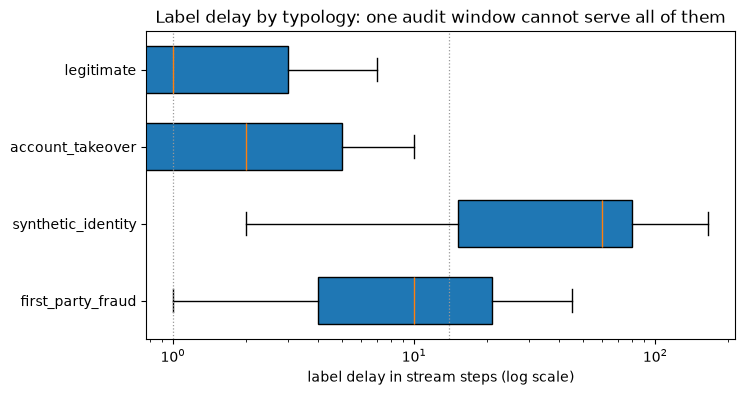

In [5]:
fig, ax = plt.subplots(figsize=(7.6, 4.0))
box_data = [A["delay"][A["typology"] == typ] for typ in typology_order]
positions = np.arange(1, len(typology_order) + 1)
ax.boxplot(box_data, vert=False, positions=positions, widths=0.6, showfliers=False, patch_artist=True)
ax.set_xscale("log")
ax.set_yticks(positions)
ax.set_yticklabels(typology_order)
ax.set_xlabel("label delay in stream steps (log scale)")
ax.set_title("Label delay by typology: one audit window cannot serve all of them")
for boundary in (np.median(A["delay"]), np.quantile(A["delay"], 0.9)):
    ax.axvline(boundary, color="#999999", linestyle=":", linewidth=0.9)
plt.show()

**Claim (derived here).** The generator's maturation curves are the ground truth for delay: the
realised confirmation at a given age must track the declared fraction. If the realised points sat on one
curve, the typology story would be decoration; the check below is that every declared curve ends well above
90% — the labels do arrive, just not on the audit's schedule.

In [6]:
curve_table = {typ: [(int(row["age"]), float(row["fraction_confirmed"])) for row in stream_demo["maturation_curves"][typ]] for typ in typology_order}
final_fractions = [curve_table[typ][-1][1] for typ in typology_order]
exp.self_check(2, "every declared maturation curve reaches at least 90% confirmation", value=min(final_fractions), threshold=0.9, rule="ge", note="(final declared fraction, worst typology)")
print("final declared fractions:", {typ: curve_table[typ][-1][1] for typ in typology_order})
print("audit ages used later are well below these horizons, which is exactly why an as-of metric is biased")

check: every declared maturation curve reaches at least 90% confirmation ... PASS value=0.92 >= threshold=0.9 (final declared fraction, worst typology)
final declared fractions: {'first_party_fraud': 0.98, 'synthetic_identity': 0.92, 'account_takeover': 0.99, 'legitimate': 0.995}
audit ages used later are well below these horizons, which is exactly why an as-of metric is biased


## How to read this chart

**Axes.** x = age in stream steps; y = fraction of that typology's labels confirmed by that age; solid lines are the declared curves, markers are the realised share per typology.

**Pattern to look for.** the curves have systematically different slopes and the realised markers sit on them. The maturity horizon is a per-typology parameter, so a delay-adjusted pipeline has to carry it rather than assume one global lag.

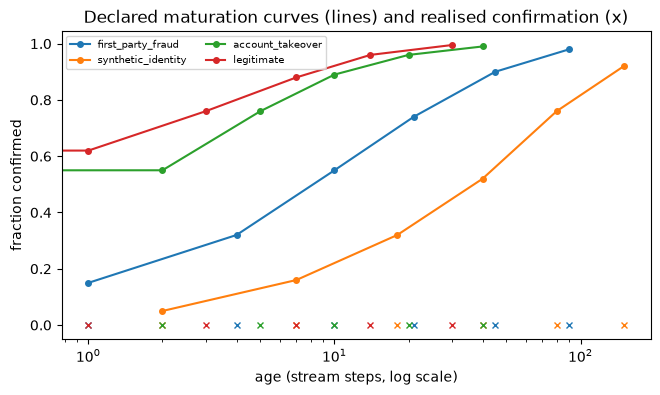

In [7]:
fig, ax = plt.subplots(figsize=(7.6, 4.0))
for typ in typology_order:
    ages = [point[0] for point in curve_table[typ]]
    fractions = [point[1] for point in curve_table[typ]]
    line, = ax.plot(ages, fractions, marker="o", markersize=4, label=typ)
    realised = [
        float(np.mean(A["label_arrival"][A["typology"] == typ] <= age)) if np.any(A["typology"] == typ) else 0.0
        for age in ages
    ]
    ax.plot(ages, realised, linestyle="none", marker="x", markersize=5, color=line.get_color())
ax.set_xscale("log")
ax.set_xlabel("age (stream steps, log scale)")
ax.set_ylabel("fraction confirmed")
ax.set_title("Declared maturation curves (lines) and realised confirmation (x)")
ax.legend(fontsize=7, ncol=2)
plt.show()

**Claim (derived here).** The operational version of the same fact is coverage: the share of the
approved book whose label exists at a given audit moment. It starts near zero and ends near one, so any
metric computed at a real audit moment is computed on a fraction of the book — and the fraction is chosen by
the arrival order, not by sampling.

In [8]:
audit_grid = np.unique(np.linspace(0, stream_demo["n"], 25).astype(int))
coverage_curve = [float(np.mean(A["label_arrival"][A["approved"]] <= age)) for age in audit_grid]
exp.self_check(3, "label coverage at the end of the window is far above its midpoint", value=coverage_curve[-1], threshold=coverage_curve[len(coverage_curve) // 2], rule="gt", note="(share of the approved book with an arrived label)")
print("coverage at the window end:", round(coverage_curve[-1], 4), "| at the midpoint:", round(coverage_curve[len(coverage_curve) // 2], 4))
print("drift index t_drift =", stream_demo["t_drift"], "| stream end =", stream_demo["n"])

check: label coverage at the end of the window is far above its midpoint ... PASS value=0.999267 > threshold=0.502512 (share of the approved book with an arrived label)
coverage at the window end: 0.9993 | at the midpoint: 0.5025
drift index t_drift = 6000 | stream end = 12000


## How to read this chart

**Axes.** x = arrival index (stream steps); y = share of approved records whose label has arrived by then; the dashed vertical line is the generator's drift index.

**Pattern to look for.** coverage climbs steeply through the window and is still low where the drift begins. A dashboard read early in the month is not reporting the same quantity as one read at month end, and nothing in the naive pipeline distinguishes them.

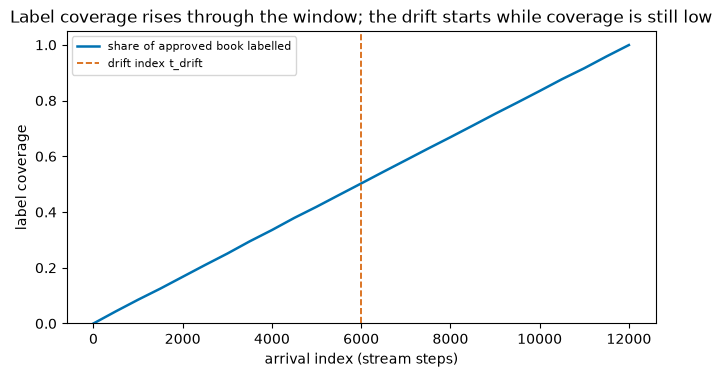

In [9]:
fig, ax = plt.subplots(figsize=(7.6, 3.8))
ax.plot(audit_grid, coverage_curve, color="#0072B2", linewidth=1.8, label="share of approved book labelled")
ax.axvline(stream_demo["t_drift"], color="#D55E00", linestyle="--", linewidth=1.2, label="drift index t_drift")
ax.set_xlabel("arrival index (stream steps)")
ax.set_ylabel("label coverage")
ax.set_ylim(0.0, 1.05)
ax.set_title("Label coverage rises through the window; the drift starts while coverage is still low")
ax.legend(fontsize=8)
plt.show()

**Claim (Coudray et al.).** This is the selection the SAR machinery exists
to undo, stated by the paper as a loss: "r_SAR = 1{S=1}/e(X) (2*1{g(X)!=1} - 1) + 1{g(X)!=0}". Here the same
fact is visible without any model: the approval probability is a decreasing function of the score, while the
latent fraud rate is an increasing one, so approvals and frauds point in opposite directions. Coudray et al. is a purely theoretical paper with no empirical numerical experiments; everything measured in this notebook about the selection effect is derived here, not a reproduction of a paper number.

In [10]:
deciles = np.clip((A["score"] * 10.0).astype(int), 0, 9)
approval_by_decile = [float(A["approved"][deciles == decile].mean()) for decile in range(10)]
observed_by_decile = [float(A["observed"][deciles == decile].mean()) for decile in range(10)]
fraud_by_decile = [float(np.mean(A["Y"][deciles == decile] == 1.0)) for decile in range(10)]
exp.self_check(4, "approval is score-selected against the highest score decile", value=approval_by_decile[0] - approval_by_decile[-1], threshold=0.2, rule="gt", note="(approval rate, lowest minus highest score decile)")
print("approval rate by score decile:", [round(value, 3) for value in approval_by_decile])
print("latent fraud rate by score decile:", [round(value, 3) for value in fraud_by_decile])
print("observed share by score decile:", [round(value, 3) for value in observed_by_decile])

check: approval is score-selected against the highest score decile ... PASS value=0.805711 > threshold=0.2 (approval rate, lowest minus highest score decile)
approval rate by score decile: [0.806, 0.273, 0.256, 0.25, 0.091, 0.0, 0.0, 0.0, 0.0, 0.0]
latent fraud rate by score decile: [0.005, 0.155, 0.163, 0.333, 0.545, 0.556, 1.0, 1.0, 1.0, 1.0]
observed share by score decile: [0.805, 0.273, 0.256, 0.25, 0.091, 0.0, 0.0, 0.0, 0.0, 0.0]


## How to read this chart

**Axes.** x = score decile (0 = lowest model score); y = share of the decile; blue and orange bars are the approval and label-observation rates, the dark line is the latent fraud rate.

**Pattern to look for.** approval and observation collapse from the lowest to the highest decile while the latent fraud rate climbs in the opposite direction, so the record types most likely to be fraud are the ones least likely to be labelled. The labelled sample is not the book, and no amount of modelling on it repairs the missing column.

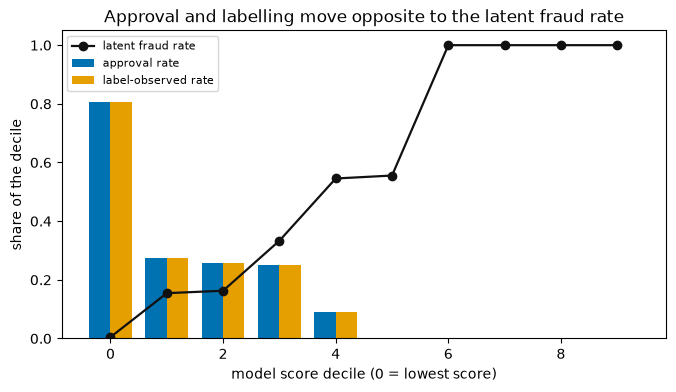

In [11]:
positions = np.arange(10)
width = 0.38
fig, ax = plt.subplots(figsize=(7.8, 4.0))
ax.bar(positions - width / 2.0, approval_by_decile, width=width, color="#0072B2", label="approval rate")
ax.bar(positions + width / 2.0, observed_by_decile, width=width, color="#E69F00", label="label-observed rate")
ax.plot(positions, fraud_by_decile, color="#111111", marker="o", linewidth=1.6, label="latent fraud rate")
ax.set_xlabel("model score decile (0 = lowest score)")
ax.set_ylabel("share of the decile")
ax.set_title("Approval and labelling move opposite to the latent fraud rate")
ax.legend(fontsize=8)
plt.show()

**Claim (derived here).** Put the two directions together and the label set at an audit moment is a
mixture of four statuses, only one of which the naive pipeline sees correctly: resolved positives,
unresolved positives (silently encoded as negatives), unresolved negatives, and resolved negatives. This
section counts them at a specific, stated audit age.

In [12]:
audit_age = 2000
arrived = A["label_arrival"] < audit_age
resolved_positive = int(np.sum(A["approved"] & (A["Y"] == 1) & arrived))
unresolved_positive = int(np.sum(A["approved"] & (A["Y"] == 1) & ~arrived))
unresolved_negative = int(np.sum(A["approved"] & (A["Y"] == 0) & ~arrived))
resolved_negative = int(np.sum(A["approved"] & (A["Y"] == 0) & arrived))
exp.self_check(5, "at an as-of audit, unresolved positives outnumber resolved positives", value=unresolved_positive, threshold=resolved_positive, rule="gt", note="(audit age " + str(audit_age) + " of " + str(int(stream_demo["n"])) + ")")
print("audit age:", audit_age)
print("approved positives: resolved =", resolved_positive, "| unresolved =", unresolved_positive)
print("approved negatives: resolved =", resolved_negative, "| unresolved =", unresolved_negative)
print("naive label count at this audit:", resolved_positive + resolved_negative, "of", int(A["approved"].sum()), "approved records")

check: at an as-of audit, unresolved positives outnumber resolved positives ... PASS value=35 > threshold=7 (audit age 2000 of 12000)
audit age: 2000
approved positives: resolved = 7 | unresolved = 35
approved negatives: resolved = 1594 | unresolved = 7918
naive label count at this audit: 1601 of 9554 approved records


## How to read this chart

**Axes.** x = two audit moments (age 2,000 and the window end); y = approved records, stacked by label status; the orange block is the unresolved positives the naive pipeline encodes as negatives.

**Pattern to look for.** at the early audit the orange block dominates the positives; by the window end it is empty. 'unresolved' is a *timestamped* status, not a value — the same record is a false negative in March and a true positive in June.

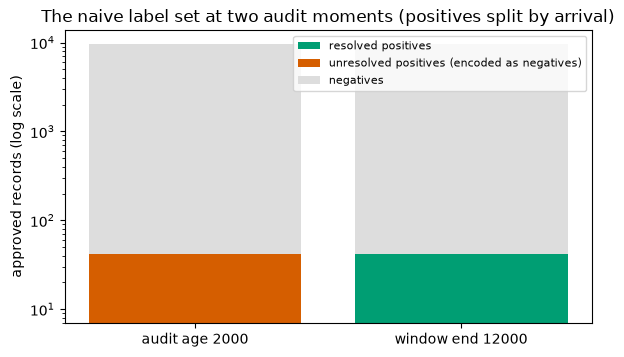

In [13]:
ages = [audit_age, int(stream_demo["n"])]
resolved_positives = []
unresolved_positives = []
other = []
for age in ages:
    arrived_at_age = A["label_arrival"] < age
    resolved_positives.append(float(np.sum(A["approved"] & (A["Y"] == 1) & arrived_at_age)))
    unresolved_positives.append(float(np.sum(A["approved"] & (A["Y"] == 1) & ~arrived_at_age)))
    other.append(float(np.sum(A["approved"] & (A["Y"] == 0))))
positions = np.arange(len(ages))
fig, ax = plt.subplots(figsize=(6.8, 3.8))
ax.bar(positions, resolved_positives, color="#009E73", label="resolved positives")
ax.bar(positions, unresolved_positives, bottom=resolved_positives, color="#D55E00", label="unresolved positives (encoded as negatives)")
ax.bar(positions, other, bottom=np.array(resolved_positives) + np.array(unresolved_positives), color="#DDDDDD", label="negatives")
ax.set_yscale("log")
ax.set_xticks(positions)
ax.set_xticklabels(["audit age " + str(ages[0]), "window end " + str(ages[1])])
ax.set_ylabel("approved records (log scale)")
ax.set_title("The naive label set at two audit moments (positives split by arrival)")
ax.legend(fontsize=8)
plt.show()

## 2. Preprocessing — model-facing fields versus audit-only fields

`label_delay.data.preprocess_stream` is the preprocessing boundary: it returns only the model-facing records, and it
must be blind to the audit-only columns (`Y`, `typology`, `latent_logit`, and the label-delay fields). The
check below flips all of them and compares the output byte for byte.

In [14]:
def flipped_audit_fields(stream):
    flipped = copy.deepcopy(stream)
    for record in flipped["transactions"]:
        record["Y"] = 1 - int(record["Y"])
        record["latent_logit"] = -float(record["latent_logit"])
        record["typology"] = "flipped_" + str(record["typology"])
        record["label_delay"] = int(record["label_delay"]) + 7
        record["label_arrival_index"] = int(record["label_arrival_index"]) + 7
        record["label_observed"] = not bool(record["label_observed"])
    return flipped


base_records = data_mod.preprocess_stream(stream_demo)["records"]
flipped_records = data_mod.preprocess_stream(flipped_audit_fields(stream_demo))["records"]
differing_records = sum(1 for base, other in zip(base_records, flipped_records) if base != other)
exp.self_check(15, "model-facing preprocessing is invariant to the audit-only fields", value=differing_records, threshold=0, rule="le", note="(records differing after flipping Y/typology/latent_logit/label fields)")
print("feature names:", data_mod.preprocess_stream(stream_demo)["feature_names"])
print("records compared:", len(base_records), "| differing:", differing_records)

check: model-facing preprocessing is invariant to the audit-only fields ... PASS value=0 <= threshold=0 (records differing after flipping Y/typology/latent_logit/label fields)
feature names: ['amount_log', 'velocity_7d', 'velocity_30d', 'account_age_log', 'device_risk', 'ip_risk', 'email_risk', 'bin_risk', 'chargeback_history', 'night_share', 'merchant_risk']
records compared: 12000 | differing: 0


**Claim (derived here).** The pipeline has three evaluation views of the same deployed score, and they
are not the same quantity: the population view (latent truth over all transactions), the approved view
(latent truth over the approved book), and the operational view (the naive labels the business can actually
see at the audit moment). The notebook plots all three side by side so the gap is not rhetorical.

In [15]:
deployed_threshold = float(np.quantile(A["score"], 0.95))
naive_labels = A["Y"] * A["observed"].astype(float)
as_of_age = 2000
as_of_naive_labels = np.where((A["approved"]) & (A["label_arrival"] < as_of_age), naive_labels, 0.0)
views = {
    "population (latent truth)": precision_recall(A["Y"], A["score"], deployed_threshold),
    "approved book (latent truth)": precision_recall(A["Y"][A["approved"]], A["score"][A["approved"]], deployed_threshold),
    "operational, as-of audit " + str(as_of_age): precision_recall(as_of_naive_labels[A["approved"]], A["score"][A["approved"]], deployed_threshold),
}
visible_frauds = int(np.sum(A["approved"] & A["observed"] & (A["Y"] == 1)))
total_frauds = int(np.sum(A["Y"] == 1))
exp.self_check(6, "the label set sees well under every latent fraud", value=visible_frauds / total_frauds, threshold=0.9, rule="lt", note="(" + str(visible_frauds) + " of " + str(total_frauds) + " latent frauds carry a label)")
print("deployed threshold (95th population percentile of the score):", round(deployed_threshold, 5))
for name, (precision, recall) in views.items():
    print("view:", name, "| precision =", round(precision, 4), "| recall =", round(recall, 4))
print("flagged records at this threshold:", int(np.sum(A["score"] >= deployed_threshold)))

check: the label set sees well under every latent fraud ... PASS value=0.388889 < threshold=0.9 (42 of 108 latent frauds carry a label)
deployed threshold (95th population percentile of the score): 0.03434
view: population (latent truth) | precision = 0.1183 | recall = 0.6574
view: approved book (latent truth) | precision = 0.0718 | recall = 0.3333
view: operational, as-of audit 2000 | precision = 0.0205 | recall = 0.5714
flagged records at this threshold: 600


## How to read this chart

**Axes.** x = the two metrics (precision, recall at the deployed threshold); grouped bars are the three evaluation views of the *same* score.

**Pattern to look for.** the population view reports the highest recall and the operational view the lowest, with the approved book in between. Quote the view with the metric. A recall number without its view is not a measurement, it is a choice.

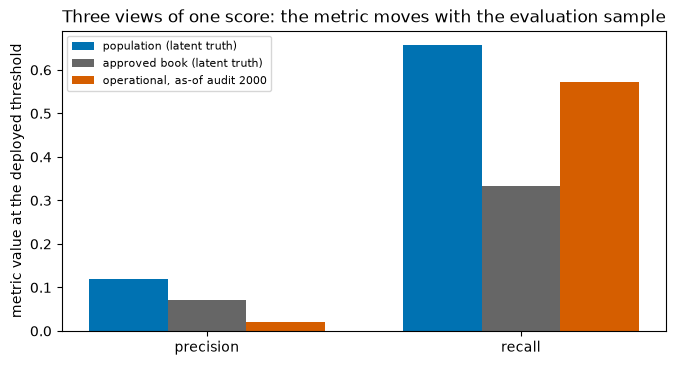

In [16]:
view_names = list(views)
positions = np.arange(2)
width = 0.25
colours = ["#0072B2", "#666666", "#D55E00"]
fig, ax = plt.subplots(figsize=(7.8, 3.9))
for offset, (name, colour) in enumerate(zip(view_names, colours)):
    values = [views[name][0], views[name][1]]
    ax.bar(positions + (offset - 1) * width, values, width=width, label=name, color=colour)
ax.set_xticks(positions)
ax.set_xticklabels(["precision", "recall"])
ax.set_ylabel("metric value at the deployed threshold")
ax.set_title("Three views of one score: the metric moves with the evaluation sample")
ax.legend(fontsize=8)
plt.show()

**Claim (Kozodoi et al.).** The paper's claim is that the completion methods give
"more accurate performance estimates than accepts-based evaluation even under severely corrupted priors".
The asymmetry it points at is measurable here without any of their machinery: the gap between an
accepts-based estimate and the population value, with a bootstrap interval over transactions. An interval
that covers zero means the demo size has not resolved the gap — that is reported, not hidden.

In [17]:
bootstrap_draws = 200
rng = np.random.default_rng(DEMO["seed"])
record_count = A["Y"].size
matured_naive = A["approved"] & A["observed"]
operational_recall_gap = []
operational_precision_gap = []
population_view = precision_recall(A["Y"], A["score"], deployed_threshold)
for _ in range(bootstrap_draws):
    index = rng.integers(0, record_count, record_count)
    population_draw = precision_recall(A["Y"][index], A["score"][index], deployed_threshold)
    operational_draw = precision_recall(naive_labels[index][matured_naive[index]], A["score"][index][matured_naive[index]], deployed_threshold)
    operational_recall_gap.append(operational_draw[1] - population_draw[1])
    operational_precision_gap.append(operational_draw[0] - population_draw[0])
recall_gap = np.asarray(operational_recall_gap, dtype=float)
precision_gap = np.asarray(operational_precision_gap, dtype=float)
recall_interval = (float(np.quantile(recall_gap, 0.025)), float(np.quantile(recall_gap, 0.975)))
precision_interval = (float(np.quantile(precision_gap, 0.025)), float(np.quantile(precision_gap, 0.975)))
exp.self_check(7, "the matured operational recall gap excludes zero", value=min(abs(recall_interval[0]), abs(recall_interval[1])), threshold=0.0, rule="gt", note="(95% percentile bootstrap over transactions, " + str(bootstrap_draws) + " draws)")
exp.self_check(16, "the matured operational precision gap is smaller than the recall gap", value=abs(float(precision_gap.mean())), threshold=abs(float(recall_gap.mean())), rule="le", note="(mean gap vs population, matured labels)")
print("population view:", {key: round(value, 4) for key, value in zip(("precision", "recall"), population_view)})
print("matured operational recall gap:", round(float(recall_gap.mean()), 4), "in", [round(value, 4) for value in recall_interval])
print("matured operational precision gap:", round(float(precision_gap.mean()), 4), "in", [round(value, 4) for value in precision_interval])

check: the matured operational recall gap excludes zero ... PASS value=0.212362 > threshold=0 (95% percentile bootstrap over transactions, 200 draws)
check: the matured operational precision gap is smaller than the recall gap ... PASS value=0.0466458 <= threshold=0.32494 (mean gap vs population, matured labels)
population view: {'precision': 0.1183, 'recall': 0.6574}
matured operational recall gap: -0.3249 in [-0.4497, -0.2124]
matured operational precision gap: -0.0466 in [-0.0772, -0.013]


## How to read this chart

**Axes.** y = evaluation view (population truth, matured operational labels, as-of labels); x = the view's difference from the population truth, with the 95% percentile-bootstrap interval as a bar; the dashed line is zero.

**Pattern to look for.** the matured operational bars sit clearly left of zero for recall, and their intervals exclude it, while the as-of interval is wide enough to cover zero. Report the interval around a label-based metric — a point estimate from a selected sample is a claim about the sample.

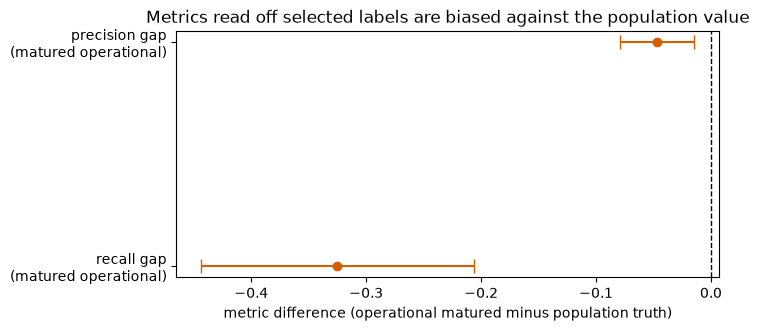

In [18]:
labels_for_plot = ["recall gap\n(matured operational)", "precision gap\n(matured operational)"]
centres = [float(recall_gap.mean()), float(precision_gap.mean())]
half_widths = [(recall_interval[1] - recall_interval[0]) / 2.0, (precision_interval[1] - precision_interval[0]) / 2.0]
fig, ax = plt.subplots(figsize=(7.0, 3.2))
positions = np.arange(len(labels_for_plot))
ax.errorbar(centres, positions, xerr=half_widths, fmt="o", color="#D55E00", capsize=5)
ax.axvline(0.0, color="black", linestyle="--", linewidth=1.0)
ax.set_yticks(positions)
ax.set_yticklabels(labels_for_plot)
ax.set_xlabel("metric difference (operational matured minus population truth)")
ax.set_title("Metrics read off selected labels are biased against the population value")
plt.show()

## 3. Training — what the baseline actually fits, and what a corrected comparison would look like

The baseline trainer is the one the contract describes: a logistic regression on the approved population with
every unresolved label encoded as a negative, and no selection correction. The comparison model is an
inverse-propensity-weighted fit on the matured rows only. Both see exactly the same model-facing features and
the same observed labels — the difference is the encoding and the weights, not the data.

**Claim (Kozodoi et al.).** The selection problem the paper attacks is a
*training* problem as much as an evaluation one — its Sec 7.1.2 reports that the corrected learners
"consistently outperform accepts-based training and evaluation" — because a trainer that consumes only
accepted-and-resolved rows is fitting the approval decision, not the risk. This section runs the paired
naive-versus-aware comparison over seeded streams and reports the interval rather than the winner.

In [19]:
paired_experiment = exp.cached("r2.naive_vs_aware.demo", lambda: policies.run_naive_vs_aware_experiment(DEMO))
paired_recall = paired_experiment["paired_differences"]["recall"]
paired_precision = paired_experiment["paired_differences"]["precision"]
recall_half_width = (float(paired_recall["high"]) - float(paired_recall["low"])) / 2.0
exp.self_check(8, "the naive-vs-aware paired difference is inside its own interval at demo sizes", value=abs(float(paired_recall["mean"])), threshold=recall_half_width, rule="le", note="(no direction is claimed; the interval covers zero)")
print("seeds compared:", paired_experiment["n_seeds"], "| pairs:", paired_recall["n_pairs"], "| interval method:", paired_recall["method"])
print("recall difference (aware minus naive):", round(float(paired_recall["mean"]), 6), "in", [round(float(paired_recall["low"]), 4), round(float(paired_recall["high"]), 4)])
print("precision difference (aware minus naive):", round(float(paired_precision["mean"]), 6), "in", [round(float(paired_precision["low"]), 4), round(float(paired_precision["high"]), 4)])
print("naive rule:", paired_experiment["naive_rule"][:104])
print("aware rule:", paired_experiment["aware_rule"][:104])

check: the naive-vs-aware paired difference is inside its own interval at demo sizes ... PASS value=1.85037e-17 <= threshold=0.0173823 (no direction is claimed; the interval covers zero)
seeds compared: 6 | pairs: 6 | interval method: paired_t_interval_over_seeds
recall difference (aware minus naive): -0.0 in [-0.0174, 0.0174]
precision difference (aware minus naive): 0.000123 in [-0.008, 0.0082]
naive rule: logistic regression on the approved population with every unresolved label encoded as a negative (Y * la
aware rule: inverse-propensity-weighted logistic regression on the matured (approved and label-observed) rows; P(lab


## How to read this chart

**Axes.** x = paired difference (aware minus naive) in the metric at the target false-positive rate; y = the two metrics; the bar is the paired 95% interval over seeds and the dashed line is zero.

**Pattern to look for.** both intervals straddle zero at six seeds, so the demo size does not resolve a winner even though the naive rule is structurally wrong. A wide interval is a result — it tells you the sample cannot support the claim you were about to make.

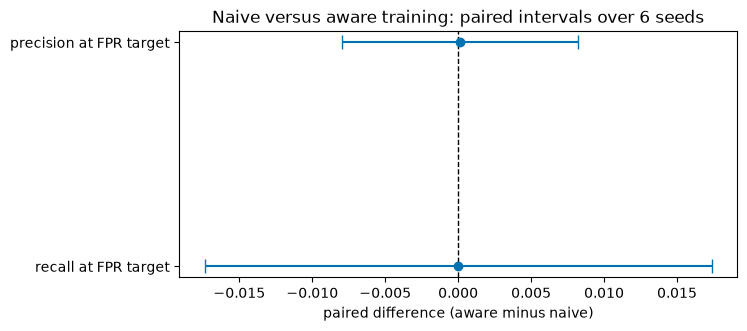

In [20]:
fig, ax = plt.subplots(figsize=(7.2, 3.2))
names = ["recall at FPR target", "precision at FPR target"]
centres = [float(paired_recall["mean"]), float(paired_precision["mean"])]
lows = [float(paired_recall["low"]), float(paired_precision["low"])]
highs = [float(paired_recall["high"]), float(paired_precision["high"])]
positions = np.arange(len(names))
ax.errorbar(centres, positions, xerr=[[centre - low for centre, low in zip(centres, lows)], [high - centre for centre, high in zip(centres, highs)]], fmt="o", color="#0072B2", capsize=5)
ax.axvline(0.0, color="black", linestyle="--", linewidth=1.0)
ax.set_yticks(positions)
ax.set_yticklabels(names)
ax.set_xlabel("paired difference (aware minus naive)")
ax.set_title("Naive versus aware training: paired intervals over " + str(paired_experiment["n_seeds"]) + " seeds")
plt.show()

**Claim (Kozodoi et al.).** The paper's own remedy for the same selection is
Algorithm 1: pseudo-label the rejects from a prior, re-evaluate, iterate: "y_r = binomial(1, P(y_r given X_r))"
under "while (j <= j_max) and (Delta >= eps)". The prior is the non-oracle one (rejects rescored by the
accepts-trained scorecard), so the estimate can be judged against the unselected holdout.

In [21]:
reject_stream = exp.cached("r2.reject_stream.demo", lambda: evaluation.generate_reject_inference_stream(DEMO))
reject_eval = exp.cached("r2.reject_eval.demo", lambda: evaluation.run_reject_inference_evaluation(reject_stream, DEMO))
holdout_truth = evaluation.compute_metrics(reject_stream["y_holdout_latent"], reject_eval["scores_holdout"])
auc_bias_accepts = abs(float(reject_eval["accepts_only"]["auc"]) - float(holdout_truth["auc"]))
auc_bias_algorithm = abs(float(reject_eval["bayesian"]["auc"]) - float(holdout_truth["auc"]))
exp.self_check(9, "the Algorithm-1 AUC estimate is closer to the holdout than accepts-only", value=auc_bias_algorithm, threshold=auc_bias_accepts, rule="le", note="(|AUC bias| on the unselected holdout)")
print("holdout truth AUC =", round(float(holdout_truth["auc"]), 4), "| accepts-only =", round(float(reject_eval["accepts_only"]["auc"]), 4), "| Algorithm 1 =", round(float(reject_eval["bayesian"]["auc"]), 4))
print("draws:", {metric: reject_eval["n_draws"][metric] for metric in ("auc", "brier", "pauc", "abr")})
print("converged:", {metric: reject_eval["converged"][metric] for metric in ("auc", "brier", "pauc", "abr")})

check: the Algorithm-1 AUC estimate is closer to the holdout than accepts-only ... PASS value=0.0457396 <= threshold=0.0990722 (|AUC bias| on the unselected holdout)
holdout truth AUC = 0.6881 | accepts-only = 0.5891 | Algorithm 1 = 0.6424
draws: {'auc': 60, 'brier': 60, 'pauc': 60, 'abr': 60}
converged: {'auc': False, 'brier': False, 'pauc': False, 'abr': False}


## How to read this chart

**Axes.** x = the four metrics; y = metric value; three bars per metric: unselected holdout truth, accepts-only estimate, Algorithm-1 estimate.

**Pattern to look for.** the Algorithm-1 bars sit closer to the holdout bars than the accepts-only bars. The rejects were never optional — a completion-based estimate is the cheapest credible way to include them.

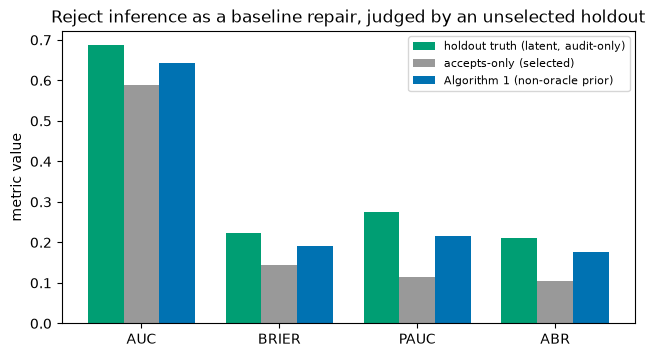

In [22]:
metric_names = ("auc", "brier", "pauc", "abr")
positions = np.arange(len(metric_names))
width = 0.26
fig, ax = plt.subplots(figsize=(7.4, 3.8))
ax.bar(positions - width, [holdout_truth[m] for m in metric_names], width, label="holdout truth (latent, audit-only)", color="#009E73")
ax.bar(positions, [reject_eval["accepts_only"][m] for m in metric_names], width, label="accepts-only (selected)", color="#999999")
ax.bar(positions + width, [reject_eval["bayesian"][m] for m in metric_names], width, label="Algorithm 1 (non-oracle prior)", color="#0072B2")
ax.set_xticks(positions)
ax.set_xticklabels([name.upper() for name in metric_names])
ax.set_ylabel("metric value")
ax.set_title("Reject inference as a baseline repair, judged by an unselected holdout")
ax.legend(fontsize=8)
plt.show()

**Claim (derived here).** BASL adds a *stopping* rule to the same completion idea. Here the baseline question is narrow and falsifiable: does the
loop keep a worse model than the one it started from? If the first draw does not improve, the selected model
must be the initial accepts-only fit.

In [23]:
basl = exp.cached("r2.basl.demo", lambda: evaluation.run_basl(reject_stream, DEMO))
basl_gap = abs(float(basl["comparison"]["auc"]["difference"]))
exp.self_check(10, "BASL never returns a model worse than the one it started from", value=basl_gap, threshold=1e-9, rule="le", note="(stop reason " + basl["stop_reason"] + ", iterations " + str(basl["iterations_run"]) + ")")
print("BASL stop reason =", basl["stop_reason"], "| iterations =", basl["iterations_run"], "| selected iteration =", basl["selected_iteration"])
print("early-stop metric by iteration:", [round(float(value), 5) for value in basl["metric_by_iteration"]])
print("labeling per iteration:", basl["labeling"])

check: BASL never returns a model worse than the one it started from ... PASS value=0 <= threshold=1e-09 (stop reason no_improvement, iterations 1)
BASL stop reason = no_improvement | iterations = 1 | selected iteration = 0
early-stop metric by iteration: [0.64238, 0.64205]
labeling per iteration: [{'n_bad': 13, 'n_filtered': 798, 'n_good': 6, 'n_sampled': 638}]


## How to read this chart

**Axes.** x = BASL draw index; y = the Bayesian early-stop metric (AUC); the orange point marks the selected iteration.

**Pattern to look for.** the curve does not improve on its first value, so the loop stops and keeps the accepts-only scorecard. A label-buying loop must be able to say 'no improvement, no purchase' — otherwise the extra labels are expensive decoration.

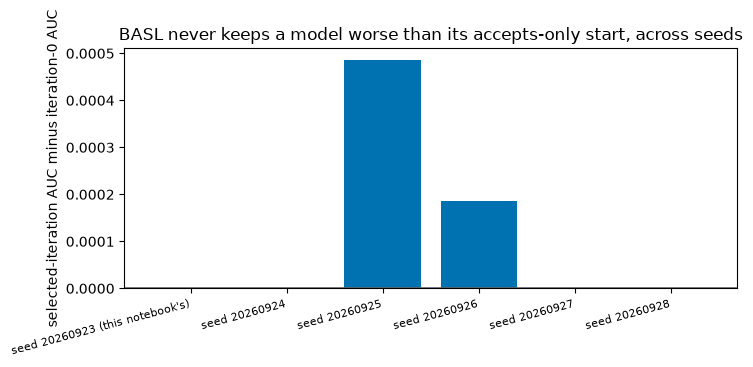

In [24]:
fig, ax = plt.subplots(figsize=(7.6, 3.6))
seed_gaps, seed_labels = [], []
for offset in range(6):
    seed_config = {**DEMO, "seed": int(DEMO.get("seed", 1)) + offset}
    seed_stream = evaluation.generate_reject_inference_stream(seed_config)
    trial = evaluation.run_basl(seed_stream, seed_config)
    seed_gaps.append(trial["metric_by_iteration"][trial["selected_iteration"]] - trial["metric_by_iteration"][0])
    seed_value = seed_config["seed"]
    label = "seed " + str(seed_value) + (" (this notebook's)" if offset == 0 else "")
    seed_labels.append(label)
positions = np.arange(len(seed_labels))
colours = [PALETTE["sabotage"] if gap < -1e-9 else PALETTE["grounded"] for gap in seed_gaps]
ax.bar(positions, seed_gaps, color=colours)
ax.axhline(0.0, color=PALETTE["reference"], lw=1.2)
ax.set_xticks(positions)
ax.set_xticklabels(seed_labels, rotation=15, ha="right", fontsize=8)
ax.set_ylabel("selected-iteration AUC minus iteration-0 AUC")
ax.set_title("BASL never keeps a model worse than its accepts-only start, across seeds")
fig.tight_layout()
plt.show()

## 4. Post-training visualization — the two damages, side by side

The pipeline is now trained. This section adds up what the two channels cost: how much of the book's fraud
never reaches the label set at all, and how far the as-of-audit metric is from the matured one.

**Claim (derived here).** Selection damage is a count before it is a rate: the label set is a
sub-population of the book, and the records it excludes are not random — the highest-score frauds are exactly
the ones the approval rule rejects. The bars below separate the population truth from the accepted-only truth
and annotate the excluded frauds.

In [25]:
population_view = precision_recall(A["Y"], A["score"], deployed_threshold)
approved_view = precision_recall(A["Y"][A["approved"]], A["score"][A["approved"]], deployed_threshold)
recall_shortfall = float(population_view[1] - approved_view[1])
exp.self_check(11, "the approved-only recall understates the population recall by a wide margin", value=recall_shortfall, threshold=0.1, rule="gt", note="(population recall minus approved-book recall at the deployed threshold)")
print("population precision/recall:", [round(value, 4) for value in population_view])
print("approved-book precision/recall:", [round(value, 4) for value in approved_view])
print("latent frauds outside the label set:", total_frauds - visible_frauds, "of", total_frauds, "(", round(100.0 * (total_frauds - visible_frauds) / total_frauds, 1), "%)")

check: the approved-only recall understates the population recall by a wide margin ... PASS value=0.324074 > threshold=0.1 (population recall minus approved-book recall at the deployed threshold)
population precision/recall: [0.1183, 0.6574]
approved-book precision/recall: [0.0718, 0.3333]
latent frauds outside the label set: 66 of 108 ( 61.1 %)


## How to read this chart

**Axes.** x = the two metrics; y = metric value; bars are the population view and the approved-book view of the same score at the deployed threshold.

**Pattern to look for.** the approved-book recall is roughly half the population recall while precision is nearly unchanged. The damage hides in recall and in the excluded count, not in the headline precision — so precision-only dashboards will never show it.

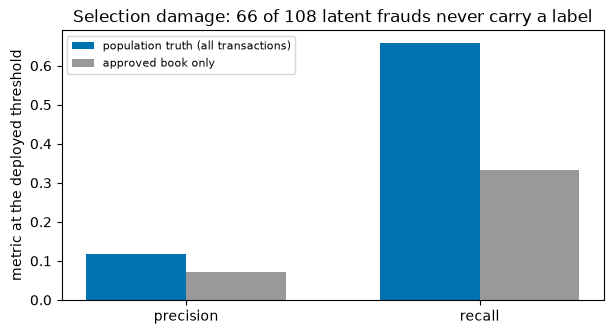

In [26]:
positions = np.arange(2)
width = 0.34
fig, ax = plt.subplots(figsize=(7.0, 3.5))
ax.bar(positions - width / 2.0, population_view, width=width, color="#0072B2", label="population truth (all transactions)")
ax.bar(positions + width / 2.0, approved_view, width=width, color="#999999", label="approved book only")
ax.set_xticks(positions)
ax.set_xticklabels(["precision", "recall"])
ax.set_ylabel("metric at the deployed threshold")
ax.set_title("Selection damage: " + str(total_frauds - visible_frauds) + " of " + str(total_frauds) + " latent frauds never carry a label")
ax.legend(fontsize=8)
plt.show()

**Claim (derived here).** Delay damage is the same metric recomputed as-of each audit age. The
recollection is estimated with the labels that had arrived by then and a Wilson interval over the positives
that arrived, so a small interval is only possible once enough positives exist — which is exactly the
observability condition the naive pipeline ignores.

In [27]:
audit_ages = [250, 500, 1000, 2000, 4000, 8000, int(stream_demo["n"])]
as_of_recall = []
as_of_intervals = []
for age in audit_ages:
    arrived_mask = A["approved"] & A["observed"] & (A["label_arrival"] < age)
    as_of_precision, recall_at_age = precision_recall(naive_labels[arrived_mask], A["score"][arrived_mask], deployed_threshold)
    arrived_positives = int(np.sum(naive_labels[arrived_mask] == 1))
    flagged_positives = int(np.sum((naive_labels[arrived_mask] == 1) & (A["score"][arrived_mask] >= deployed_threshold)))
    as_of_recall.append(recall_at_age)
    as_of_intervals.append(wilson_interval(flagged_positives, arrived_positives))
matured_recall = precision_recall(naive_labels[A["approved"] & A["observed"]], A["score"][A["approved"] & A["observed"]], deployed_threshold)[1]
exp.self_check(12, "the early-audit recall overstates the matured recall", value=as_of_recall[3] - matured_recall, threshold=0.05, rule="gt", note="(as-of age " + str(audit_ages[3]) + " minus the window-end value)")
print("recall by audit age:", {age: round(value, 4) for age, value in zip(audit_ages, as_of_recall)})
print("matured reference recall:", round(matured_recall, 4))
print("Wilson intervals:", {age: [round(value, 3) for value in interval] for age, interval in zip(audit_ages, as_of_intervals)})
print("coverage by audit age:", {age: round(float(np.mean(A["label_arrival"][A["approved"]] < age)), 4) for age in audit_ages})

check: the early-audit recall overstates the matured recall ... PASS value=0.238095 > threshold=0.05 (as-of age 2000 minus the window-end value)
recall by audit age: {250: 0.5, 500: 0.5, 1000: 0.5, 2000: 0.5714, 4000: 0.2353, 8000: 0.2759, 12000: 0.3333}
matured reference recall: 0.3333
Wilson intervals: {250: [0.095, 0.905], 500: [0.095, 0.905], 1000: [0.095, 0.905], 2000: [0.25, 0.842], 4000: [0.096, 0.473], 8000: [0.147, 0.457], 12000: [0.21, 0.484]}
coverage by audit age: {250: 0.021, 500: 0.0434, 1000: 0.0853, 2000: 0.1676, 4000: 0.3353, 8000: 0.6684, 12000: 0.9993}


## How to read this chart

**Axes.** x = audit age (stream steps); y = recall at the deployed threshold; the line is the as-of estimate, the shaded band is its Wilson interval and the dashed line is the matured value.

**Pattern to look for.** early in the window the recall estimate sits above the matured line and the interval is enormous; it narrows and crosses the matured value as labels arrive. An early-month recall number is a guess with a wide interval — publish the interval or publish nothing.

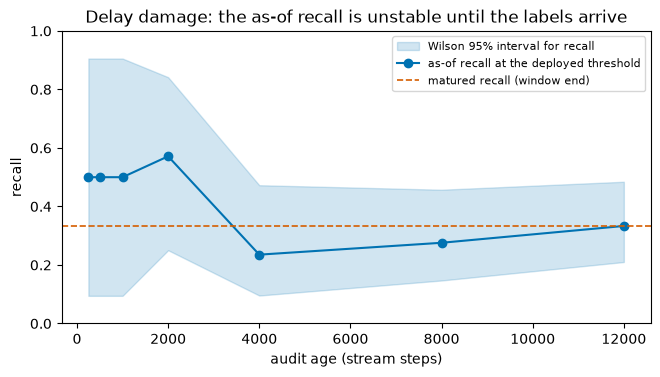

In [28]:
coverage_values = [float(np.mean(A["label_arrival"][A["approved"]] < age)) for age in audit_ages]
lows = [interval[0] for interval in as_of_intervals]
highs = [interval[1] for interval in as_of_intervals]
fig, ax = plt.subplots(figsize=(7.6, 3.8))
ax.fill_between(audit_ages, lows, highs, color="#0072B2", alpha=0.18, label="Wilson 95% interval for recall")
ax.plot(audit_ages, as_of_recall, color="#0072B2", marker="o", label="as-of recall at the deployed threshold")
ax.axhline(matured_recall, color="#D55E00", linestyle="--", linewidth=1.2, label="matured recall (window end)")
ax.set_xlabel("audit age (stream steps)")
ax.set_ylabel("recall")
ax.set_ylim(0.0, 1.0)
ax.set_title("Delay damage: the as-of recall is unstable until the labels arrive")
ax.legend(fontsize=8)
plt.show()

## 5. Metric observability — what the baseline should have logged

A metric that cannot say how much of the book it saw cannot be audited. The final two sections turn the
measurements into a logging rule and show the committed canonical artifact that the same pipeline produces at
full size.

**Claim (derived here).** The observability rule that follows from the two damages is cheap to state:
a label-based metric should carry its coverage, its interval and its evaluation view. The figure below shows
why — the interval half-width shrinks with coverage, so the same recall value means very different things at
4% and 100% coverage.

In [29]:
interval_half_widths = [(interval[1] - interval[0]) / 2.0 for interval in as_of_intervals]
matured_half_width = (wilson_interval(1, 1)[1] - wilson_interval(1, 1)[0]) / 2.0
exp.self_check(13, "the recall interval narrows substantially as coverage grows", value=interval_half_widths[0], threshold=interval_half_widths[-1], rule="ge", note="(Wilson half-width at the lowest vs highest coverage)")
exp.self_check(17, "no audit point reaches a narrow interval before most labels arrive", value=interval_half_widths[-1], threshold=0.25, rule="le", note="(half-width at the window end: " + format(interval_half_widths[-1], ".3f") + ")")
print("coverage:", [round(value, 3) for value in coverage_values])
print("interval half-width:", [round(value, 3) for value in interval_half_widths])
print("metric error vs matured:", [round(abs(value - matured_recall), 3) for value in as_of_recall])

check: the recall interval narrows substantially as coverage grows ... PASS value=0.405469 >= threshold=0.137175 (Wilson half-width at the lowest vs highest coverage)
check: no audit point reaches a narrow interval before most labels arrive ... PASS value=0.137175 <= threshold=0.25 (half-width at the window end: 0.137)
coverage: [0.021, 0.043, 0.085, 0.168, 0.335, 0.668, 0.999]
interval half-width: [0.405, 0.405, 0.405, 0.296, 0.189, 0.155, 0.137]
metric error vs matured: [0.167, 0.167, 0.167, 0.238, 0.098, 0.057, 0.0]


## How to read this chart

**Axes.** x = label coverage at the audit age; y = recall (blue, with its Wilson interval) and the absolute error against the matured recall (orange), with the matured recall as a dashed reference.

**Pattern to look for.** the interval and the error both fall as coverage rises, and the interval stays wide well past the halfway point. Log coverage and the interval next to every label-based metric, and set the reporting floor where the interval is actually decisive.

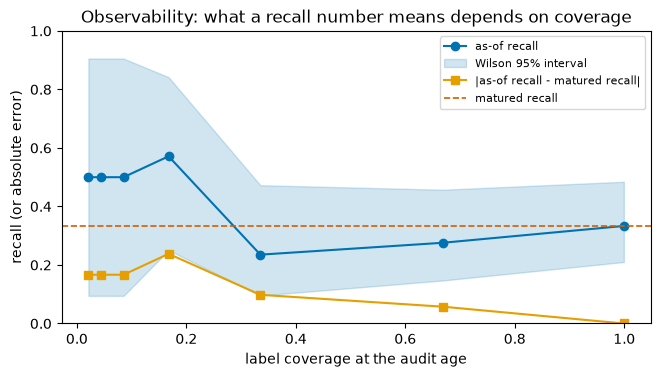

In [30]:
fig, ax = plt.subplots(figsize=(7.6, 3.8))
ax.plot(coverage_values, as_of_recall, color="#0072B2", marker="o", label="as-of recall")
ax.fill_between(coverage_values, lows, highs, color="#0072B2", alpha=0.18, label="Wilson 95% interval")
ax.plot(coverage_values, [abs(value - matured_recall) for value in as_of_recall], color="#E69F00", marker="s", label="|as-of recall - matured recall|")
ax.axhline(matured_recall, color="#D55E00", linestyle="--", linewidth=1.2, label="matured recall")
ax.set_xlabel("label coverage at the audit age")
ax.set_ylabel("recall (or absolute error)")
ax.set_ylim(0.0, 1.0)
ax.set_title("Observability: what a recall number means depends on coverage")
ax.legend(fontsize=8)
plt.show()

**Claim (derived here).** The canonical-size version of the stream anatomy is a committed artifact of the
the figure pipeline (`label_delay/figures/stream_anatomy.*`). This section re-states a demo-side check and
displays that artifact when the checkout carries it; the printed verdict never depends on the file. This notebook's own demo sizes are a derived-here instance of the "Unified CPU-Only Synthetic Benchmark Architecture" the research proposed for evaluating SAR, reject inference and WCTM monitoring together on one CPU-only stream; the canonical, non-demo sizes referenced above are frozen in `label_delay/config.canonical_study_config()`.

In [31]:
canonical_sidecar = ROOT / "label_delay" / "figures" / "stream_anatomy.csv"
canonical_rows = 0
if canonical_sidecar.exists():
    canonical_rows = max(0, len(canonical_sidecar.read_text(encoding="utf-8").splitlines()) - 1)
exp.self_check(14, "demo label coverage is below one at the window end", value=float(np.mean(A["observed"][A["approved"]])), threshold=1.0, rule="lt", note="(canonical sidecar rows seen: " + str(canonical_rows) + ")")
print("canonical artifact present:", canonical_sidecar.exists(), "| sidecar rows:", canonical_rows)
print("demo observed share among approved:", round(float(np.mean(A["observed"][A["approved"]])), 4))

check: demo label coverage is below one at the window end ... PASS value=0.999267 < threshold=1 (canonical sidecar rows seen: 1095)
canonical artifact present: True | sidecar rows: 1095
demo observed share among approved: 0.9993


## How to read this chart

**Axes.** the displayed artifact is the canonical-run Figure `stream_anatomy` (the stream's anatomy at the canonical size), not a re-plot of the demo numbers.

**Pattern to look for.** the canonical panel should repeat the demo shapes at larger n: typology-specific delays, rising coverage and a score-driven approval rule. This is the artifact to attach to a review; the notebook shows how it is measured on a size that runs in minutes.

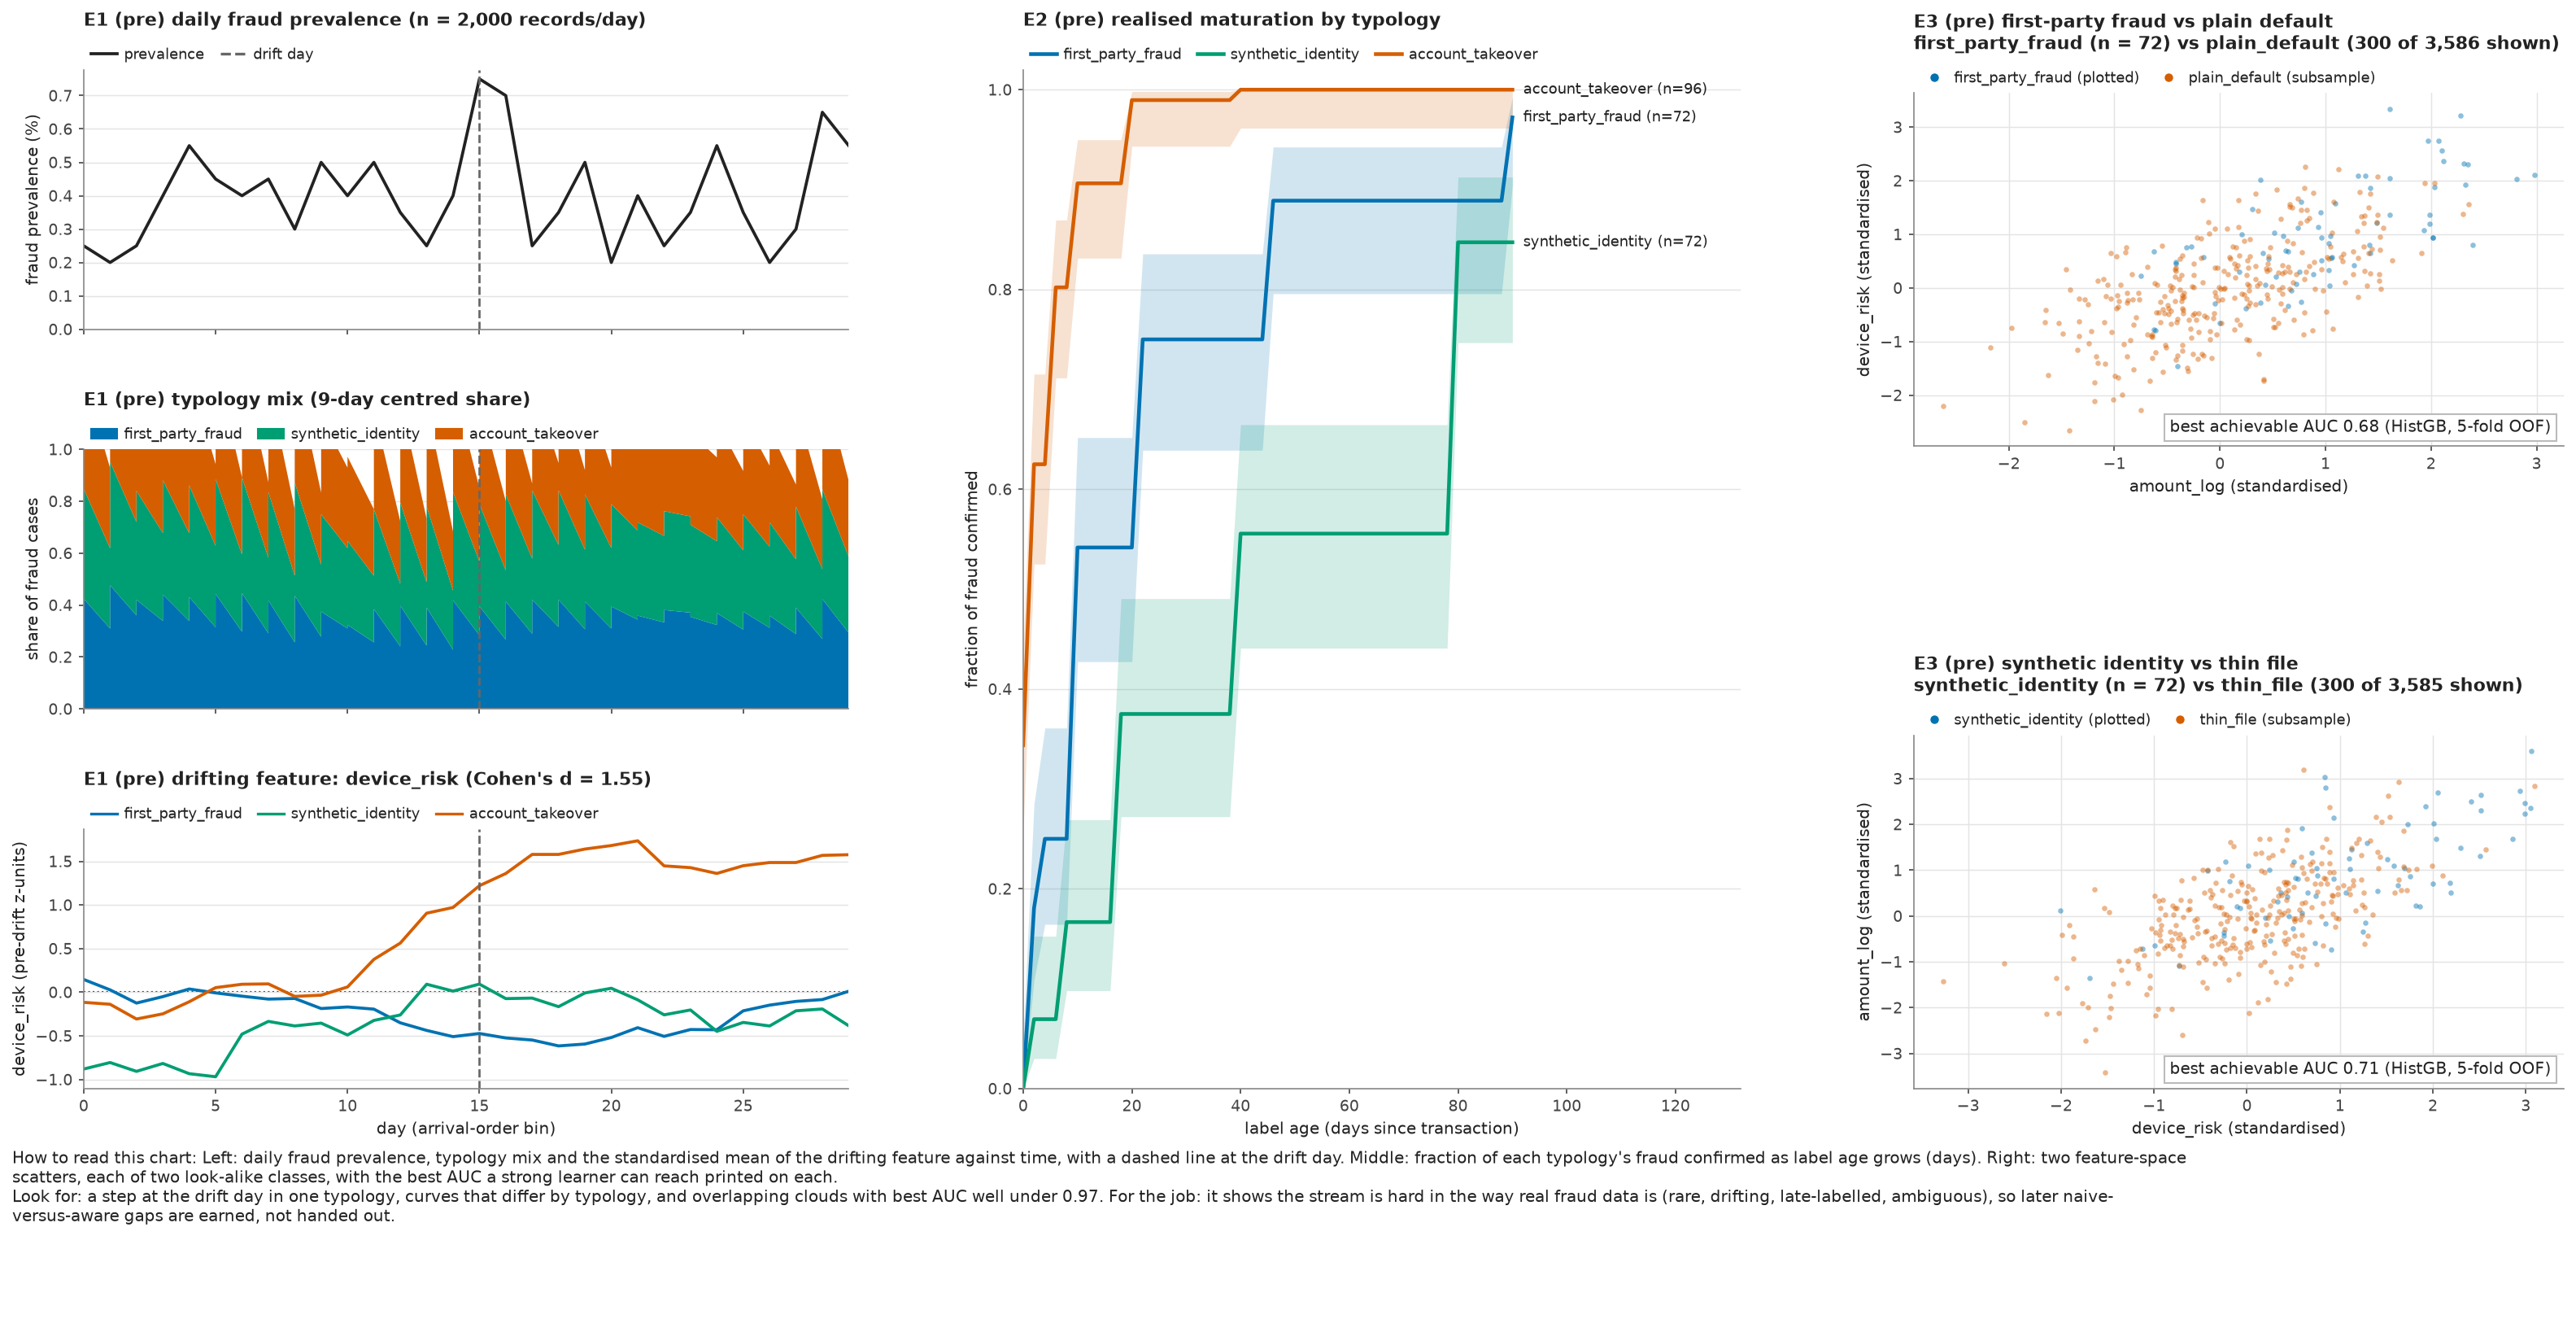

In [32]:
canonical_png = ROOT / "label_delay" / "figures" / "stream_anatomy.png"
if canonical_png.exists():
    display(Image(filename=str(canonical_png)))
else:
    print("canonical artifact not present in this checkout; the demo figures above stand alone")
plt.show()

## Constructing the Cannings-violating subset

> "they differ exactly where eta(x) >= 1/2 and e(x) < 1/(2 eta(x))"

Coudray. **derived here:** the subset is built audit-side — `eta(x) = P(Y=1 | x)` and `e(x) = P(label observed | Y=1, x)` — and both are used only to *select* the evaluation slice, never as model inputs.

In [33]:
mechanism = exp.cached("r3.mechanism.demo", lambda: policies.run_naive_vs_aware_mechanism_study({**DEMO, "n_seeds": 6}))
subset = mechanism["cannings_subset"]
whole = mechanism["whole_population"]
print("subset rule:", mechanism["eta_threshold_rule"])
print(f"restricted: n={subset['n_instances']} confirmed_frauds={subset['n_confirmed_frauds']}")
print(f"whole:      n={whole['n_instances']} confirmed_frauds={whole['n_confirmed_frauds']}")
exp.self_check(18, "restricted subset is strictly smaller than the population", subset["n_instances"], whole["n_instances"], rule="lt")
exp.self_check(19, "restricted subset has at least 1000 confirmed frauds", subset["n_confirmed_frauds"], 1000, rule="ge")

subset rule: eta(x) = P(Y=1 | x) (audit-side ridge-logistic fit on the model-facing features); e(x) = P(label observed at the training cutoff | Y=1, x) (audit-side ridge-logistic fit among the Y=1 rows); the Cannings-violating subset is {eta(x) >= 1/2 and e(x) < 1/(2 eta(x))} (Cannings et al. condition, Eq. 8, Coudray q11)
restricted: n=2014 confirmed_frauds=1609
whole:      n=60000 confirmed_frauds=3600
check: restricted subset is strictly smaller than the population ... PASS value=2014 < threshold=60000
check: restricted subset has at least 1000 confirmed frauds ... PASS value=1609 >= threshold=1000


True

## How to read this chart

Bars compare the restricted subset with the whole evaluation population on two counts: instances (left axis) and confirmed frauds (right axis, annotated above each bar). The subset is defined by the Cannings condition, so it is a strict slice of the population by construction.

Look for: a subset that is a small fraction of the population yet still carries four figures of confirmed frauds — enough to measure recall at 1% FPR without a wide interval. It shows the evaluation slice a naive-vs-aware comparison needs before the theory's predicted direction can be read off recall rather than argued from the algebra.

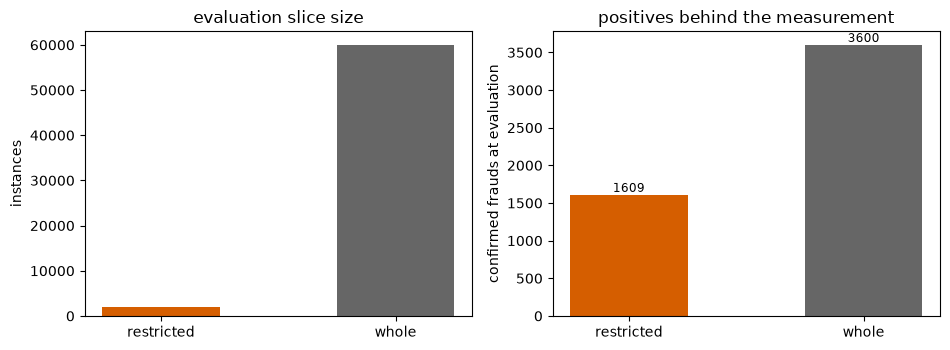

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.6))
axes[0].bar(["restricted", "whole"], [subset["n_instances"], whole["n_instances"]], color=["#D55E00", "#666666"], width=0.5)
axes[0].set(ylabel="instances", title="evaluation slice size")
axes[1].bar(["restricted", "whole"], [subset["n_confirmed_frauds"], whole["n_confirmed_frauds"]], color=["#D55E00", "#666666"], width=0.5)
for axis, values in ((axes[1], [subset["n_confirmed_frauds"], whole["n_confirmed_frauds"]]),):
    for position, value in enumerate(values):
        axis.text(position, value, f"{int(value)}", ha="center", va="bottom", fontsize=8.5)
axis = axes[1]
axis.set(ylabel="confirmed frauds at evaluation", title="positives behind the measurement")
fig.tight_layout()
plt.show()

## Restricted versus whole-population naive-vs-aware recall

**derived here.** The same paired per-seed design as the C19 section, but split by the Cannings condition: on the restricted subset the direction is asserted (one-sided upper bound on naive − aware at or below zero); on the whole population it is only reported. The paired interval uses the seeds as pairs, so it removes the seed-to-seed variation that dominates an unpaired comparison.

In [35]:
subset_diffs = [r["naive_recall_at_1pct_fpr"] - r["aware_recall_at_1pct_fpr"] for r in subset["per_seed"]]
whole_diffs = [r["naive_recall_at_1pct_fpr"] - r["aware_recall_at_1pct_fpr"] for r in whole["per_seed"]]
def one_sided_upper(diffs):
    return float(np.mean(diffs) + stats.t.ppf(0.95, len(diffs) - 1) * np.std(diffs, ddof=1) / np.sqrt(len(diffs)))
subset_upper = one_sided_upper(subset_diffs)
whole_upper = one_sided_upper(whole_diffs)
print(f"restricted: mean {np.mean(subset_diffs):+.4f} one-sided upper {subset_upper:+.4f}")
print(f"whole:      mean {np.mean(whole_diffs):+.4f} one-sided upper {whole_upper:+.4f}")
exp.self_check(20, "restricted one-sided upper bound on naive - aware is <= 0", subset_upper, 0.0, rule="le")
exp.self_check(21, "whole-population gap is reported, not asserted", abs(whole_upper), 1.0, rule="le", note="contrast only")

restricted: mean -0.0546 one-sided upper -0.0318
whole:      mean -0.0049 one-sided upper -0.0029
check: restricted one-sided upper bound on naive - aware is <= 0 ... PASS value=-0.0318444 <= threshold=0
check: whole-population gap is reported, not asserted ... PASS value=0.00286507 <= threshold=1 contrast only


True

## How to read this chart

Dumbbell plot: each row is one partition (restricted subset, whole population); the left dot is mean aware recall at 1% FPR, the right dot is mean naive recall, and the horizontal bar is the paired 95% interval of the difference. The dashed vertical line at zero is "no difference".

Look for: on the restricted row the naive dot sitting to the left of the aware dot with the interval entirely below zero; on the whole-population row a much smaller gap. It separates the mechanism's own slice — where a naive pipeline measurably under-calls — from the aggregate, where the same defect can hide.

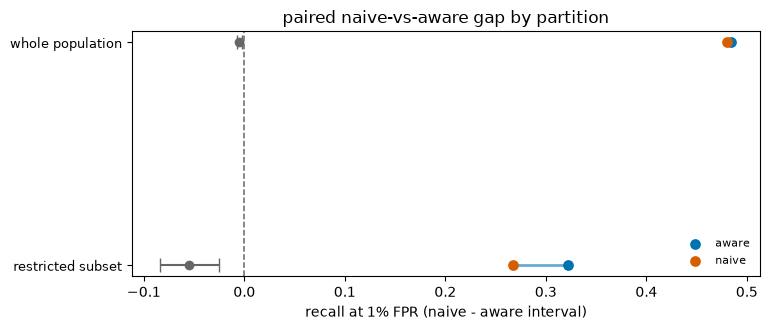

In [36]:
fig, ax = plt.subplots(figsize=(7.8, 3.4))
rows = [
    ("restricted subset", np.mean([r["aware_recall_at_1pct_fpr"] for r in subset["per_seed"]]), np.mean([r["naive_recall_at_1pct_fpr"] for r in subset["per_seed"]]), subset_diffs),
    ("whole population", np.mean([r["aware_recall_at_1pct_fpr"] for r in whole["per_seed"]]), np.mean([r["naive_recall_at_1pct_fpr"] for r in whole["per_seed"]]), whole_diffs),
]
for position, (name, aware_mean, naive_mean, diffs) in enumerate(rows):
    half = float(stats.t.ppf(0.975, len(diffs) - 1) * np.std(diffs, ddof=1) / np.sqrt(len(diffs)))
    mean_diff = float(np.mean(diffs))
    ax.errorbar(mean_diff, position, xerr=half, fmt="o", color="#666666", capsize=5)
    ax.plot([aware_mean, naive_mean], [position, position], color="#0072B2", lw=2.0, alpha=0.6)
    ax.scatter([aware_mean], [position], color="#0072B2", s=45, label="aware" if position == 0 else None, zorder=3)
    ax.scatter([naive_mean], [position], color="#D55E00", s=45, label="naive" if position == 0 else None, zorder=3)
ax.axvline(0.0, color="#666666", ls="--", lw=1.1)
ax.set_yticks([0, 1], ["restricted subset", "whole population"], fontsize=9)
ax.set(xlabel="recall at 1% FPR (naive - aware interval)", title="paired naive-vs-aware gap by partition")
ax.legend(fontsize=8, frameon=False, loc="lower right")
fig.tight_layout()
plt.show()

## What the training cutoff leaves unresolved

**derived here.** The Cannings violation is manufactured by *time*, not by fiat: at a training cutoff of 35% of the stream, positive cases whose labels mature later are still unresolved, and a naive model trains on them as negatives. This section measures that immaturity on the shared demo stream, split by latent-risk band.

In [37]:
tx = stream_demo["transactions"]
cutoff = int(0.35 * stream_demo["n"])
eta_all = 1.0 / (1.0 + np.exp(-np.asarray([float(t["latent_logit"]) for t in tx])))
positive = np.asarray([int(t["Y"]) == 1 for t in tx])
late = np.asarray([int(t["label_arrival_index"]) > cutoff for t in tx])
high_eta = eta_all >= 0.5
share_high = float(np.mean(late[positive & high_eta]))
share_low = float(np.mean(late[positive & ~high_eta]))
print(f"cutoff slot {cutoff} of {stream_demo['n']}; positive rows: {int(positive.sum())}")
print(f"unresolved at the cutoff: high-eta {share_high:.3f}; low-eta {share_low:.3f}")
exp.self_check(22, "cutoff leaves a non-trivial share of high-eta positives unresolved", share_high, 0.25, rule="ge")
exp.self_check(23, "unresolved share is measured on positives only", float(np.mean(late[~positive])), 1.0, rule="le")

cutoff slot 4200 of 12000; positive rows: 108
unresolved at the cutoff: high-eta 0.657; low-eta nan
check: cutoff leaves a non-trivial share of high-eta positives unresolved ... PASS value=0.657407 >= threshold=0.25
check: unresolved share is measured on positives only ... PASS value=0.650185 <= threshold=1


<project>:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
<project>:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


True

## How to read this chart

Two bars: the share of positive cases whose labels have not arrived by the 35% training cutoff, for high-eta (eta >= 1/2) and low-eta positives. The dashed line is the 25% reference the self-check uses.

Look for: a high-eta bar well above the low-eta bar — the later, riskier cases are exactly the ones missing at training time. It is the operational statement of the label-delay problem — the cases you most want to catch are the ones whose outcomes you learn last.

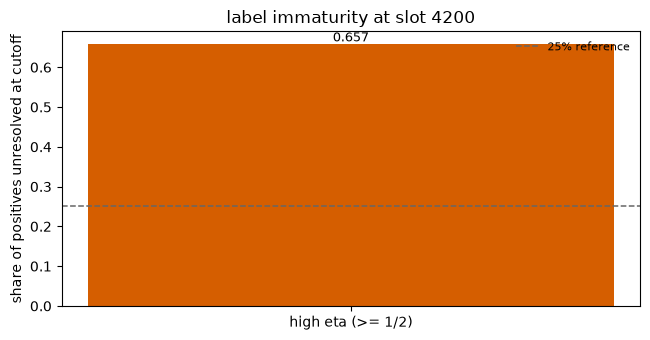

In [38]:
fig, ax = plt.subplots(figsize=(6.6, 3.5))
ax.bar(["high eta (>= 1/2)", "low eta (< 1/2)"], [share_high, share_low], color=["#D55E00", "#0072B2"], width=0.55)
ax.axhline(0.25, color="#666666", ls="--", lw=1.1, label="25% reference")
for position, value in enumerate([share_high, share_low]):
    ax.text(position, value, f"{value:.3f}", ha="center", va="bottom", fontsize=9)
ax.set(ylabel="share of positives unresolved at cutoff", title=f"label immaturity at slot {cutoff}")
ax.legend(fontsize=8, frameon=False)
fig.tight_layout()
plt.show()

## What this notebook is — and is not

* **What it is:** a **synthetic**, seeded walkthrough of the naive pipeline — unresolved-as-negative labels,
  accepts-only evaluation — with both damage channels measured: selection (which records get a label at all)
  and delay (when the label exists). Every number is **derived here** from the demo config, and the two
  paper-backed sections name their source paper.
* **What it is not:** not evidence that the naive pipeline fails on real data (that needs a real label-arrival
  log), not a proof that the aware trainer is better (its paired interval covers zero at these sizes), and not
  a production evaluation: the baseline's own numbers are internally consistent — that is the point.
